In [1]:
import numpy as np

lines = []

for tau in [0.9] + list(np.linspace(1.0, 2.0, 6)):
    if tau <= 1.0:
        for eps in [1e-2]:
            for b in list(np.linspace(0, 15, 6)):
                lam = b * eps
                # lines += [f"{tau:.2e} {lam:.2e} {eps:.2e}\n"]
                lines += [f"{tau:.4e} {lam:.4e} {eps:.4e}\n"]
    else:
        eps = 0.0
        lam = 0.0
        # lines += [f"{tau:.2e} {lam:.2e} {eps:.2e}\n"]
        lines += [f"{tau:.4e} {lam:.4e} {eps:.4e}\n"]

# print the lines with 4 digits after the decimal point
for line in lines:
    print(line, end="")

9.0000e-01 0.0000e+00 1.0000e-02
9.0000e-01 3.0000e-02 1.0000e-02
9.0000e-01 6.0000e-02 1.0000e-02
9.0000e-01 9.0000e-02 1.0000e-02
9.0000e-01 1.2000e-01 1.0000e-02
9.0000e-01 1.5000e-01 1.0000e-02
1.0000e+00 0.0000e+00 1.0000e-02
1.0000e+00 3.0000e-02 1.0000e-02
1.0000e+00 6.0000e-02 1.0000e-02
1.0000e+00 9.0000e-02 1.0000e-02
1.0000e+00 1.2000e-01 1.0000e-02
1.0000e+00 1.5000e-01 1.0000e-02
1.2000e+00 0.0000e+00 0.0000e+00
1.4000e+00 0.0000e+00 0.0000e+00
1.6000e+00 0.0000e+00 0.0000e+00
1.8000e+00 0.0000e+00 0.0000e+00
2.0000e+00 0.0000e+00 0.0000e+00


In [10]:
import pandas as pd

# load parquet file
df = pd.read_parquet("/dlabscratch1/samaier/projects/antidistillation-sampling-safety/experiments/full_pipeline_run2/traces/tau1.00e+00_lam3.00e-02_eps1.00e-02.parquet")

df.head()

,problem,solution,input_ids,trace,is_raw_correct,trace_af,is_af_correct
0,Natalia sold clips to 48 of her friends in Apr...,Natalia sold 48/2 = <<48/2=24>>24 clips in May...,"[151646, 2610, 525, 264, 6888, 11079, 13, 1446...",<｜begin▁of▁sentence｜>You are a math teacher. Y...,True,<｜begin▁of▁sentence｜>You are a math teacher. Y...,True
1,Weng earns $12 an hour for babysitting. Yester...,Weng earns 12/60 = $<<12/60=0.2>>0.2 per minut...,"[151646, 2610, 525, 264, 6888, 11079, 13, 1446...",<｜begin▁of▁sentence｜>You are a math teacher. Y...,False,<｜begin▁of▁sentence｜>You are a math teacher. Y...,True
2,Betty is saving money for a new wallet which c...,"In the beginning, Betty has only 100 / 2 = $<<...","[151646, 2610, 525, 264, 6888, 11079, 13, 1446...",<｜begin▁of▁sentence｜>You are a math teacher. Y...,True,<｜begin▁of▁sentence｜>You are a math teacher. Y...,True
3,"Julie is reading a 120-page book. Yesterday, s...",Maila read 12 x 2 = <<12*2=24>>24 pages today....,"[151646, 2610, 525, 264, 6888, 11079, 13, 1446...",<｜begin▁of▁sentence｜>You are a math teacher. Y...,True,<｜begin▁of▁sentence｜>You are a math teacher. Y...,True
4,James writes a 3-page letter to 2 different fr...,He writes each friend 3*2=<<3*2=6>>6 pages a w...,"[151646, 2610, 525, 264, 6888, 11079, 13, 1446...",<｜begin▁of▁sentence｜>You are a math teacher. Y...,True,<｜begin▁of▁sentence｜>You are a math teacher. Y...,True


In [11]:
num_true = df["is_raw_correct"].sum()
print(f"Number of true in is_raw_correct column: {num_true}")
print(f"Total number of rows: {len(df)}")
print(f"Proportion of true in is_raw_correct column: {num_true / len(df):.4f}")

Number of true in is_raw_correct column: 4485
Total number of rows: 5231
Proportion of true in is_raw_correct column: 0.8574


In [12]:
num_true = df["is_af_correct"].sum()
print(f"Number of true in is_raw_is_af_correctcorrect column: {num_true}")
print(f"Total number of rows: {len(df)}")
print(f"Proportion of true in is_af_correct column: {num_true / len(df):.4f}")

Number of true in is_raw_is_af_correctcorrect column: 4755
Total number of rows: 5231
Proportion of true in is_af_correct column: 0.9090


In [13]:
# method to print nicely a row of the dataframe
def print_row(row):
    print(f"Problem:\n{row['problem']}\n")
    print(f"Solution:\n{row['solution']}\n")
    print(f"Is raw correct: {row['is_raw_correct']}")
    print(f"Is AF correct: {row['is_af_correct']}")
    print(f"Trace:\n{row['trace']}\n")
    print(f"AF Trace:\n{row['trace_af']}\n")

# print the first row of the dataframe
print_row(df.iloc[0])

Problem:
Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?

Solution:
Natalia sold 48/2 = <<48/2=24>>24 clips in May.
Natalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.
#### 72

Is raw correct: True
Is AF correct: True
Trace:
<｜begin▁of▁sentence｜>You are a math teacher. You will be given a math problem and you will solve it step by step.
You will output your final solution like \boxed{ANSWER}. Be sure to include relevant units within the brackets and fully evaluate arithmetic expressions.
<｜User｜>Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
<｜Assistant｜><think>
I start by identifying the number of clips Natalia sold in April, which is 48.

Since she sold half as many clips in May, I calculate May's sales by multiplying April's sales by 1/2. This gives m

In [4]:
import os

# list all parquet files in the directory with a specific prefix
parquet_files = [f for f in os.listdir("/dlabscratch1/samaier/projects/antidistillation-sampling-safety/experiments/full_pipeline_run2/traces") if f.startswith("eval_teacher") and f.endswith(".parquet") and "lam0.00e+00" not in f]
print(f"Found {len(parquet_files)} parquet files with prefix 'eval_teacher' and suffix '.parquet' and not containing 'lam0.00e+00'")
parquet_files.sort()
for parquet_file in parquet_files:
    print(parquet_file)

Found 10 parquet files with prefix 'eval_teacher' and suffix '.parquet' and not containing 'lam0.00e+00'
eval_teacher_tau1.00e+00_lam1.20e-01_eps1.00e-02.parquet
eval_teacher_tau1.00e+00_lam1.50e-01_eps1.00e-02.parquet
eval_teacher_tau1.00e+00_lam3.00e-02_eps1.00e-02.parquet
eval_teacher_tau1.00e+00_lam6.00e-02_eps1.00e-02.parquet
eval_teacher_tau1.00e+00_lam9.00e-02_eps1.00e-02.parquet
eval_teacher_tau9.00e-01_lam1.20e-01_eps1.00e-02.parquet
eval_teacher_tau9.00e-01_lam1.50e-01_eps1.00e-02.parquet
eval_teacher_tau9.00e-01_lam3.00e-02_eps1.00e-02.parquet
eval_teacher_tau9.00e-01_lam6.00e-02_eps1.00e-02.parquet
eval_teacher_tau9.00e-01_lam9.00e-02_eps1.00e-02.parquet


In [6]:
# Load the parquet files and compute the proportion of correct answers for each file
import pandas as pd

results = []
for parquet_file in parquet_files:
    df = pd.read_parquet(f"/dlabscratch1/samaier/projects/antidistillation-sampling-safety/experiments/full_pipeline_run2/traces/{parquet_file}")
    num_true_raw = df["is_raw_correct"].sum()
    num_true_af = df["is_af_correct"].sum()
    total = len(df)
    prop_true_raw = num_true_raw / total
    prop_true_af = num_true_af / total
    results.append((parquet_file, prop_true_raw, prop_true_af))

# Print the results
for parquet_file, prop_true_raw, prop_true_af in results:
    print(f"{parquet_file}: Proportion of true in is_raw_correct: {prop_true_raw:.4f}, Proportion of true in is_af_correct: {prop_true_af:.4f}")

eval_teacher_tau1.00e+00_lam1.20e-01_eps1.00e-02.parquet: Proportion of true in is_raw_correct: 0.2696, Proportion of true in is_af_correct: 0.6410
eval_teacher_tau1.00e+00_lam1.50e-01_eps1.00e-02.parquet: Proportion of true in is_raw_correct: 0.1878, Proportion of true in is_af_correct: 0.5401
eval_teacher_tau1.00e+00_lam3.00e-02_eps1.00e-02.parquet: Proportion of true in is_raw_correct: 0.8652, Proportion of true in is_af_correct: 0.9148
eval_teacher_tau1.00e+00_lam6.00e-02_eps1.00e-02.parquet: Proportion of true in is_raw_correct: 0.5467, Proportion of true in is_af_correct: 0.8379
eval_teacher_tau1.00e+00_lam9.00e-02_eps1.00e-02.parquet: Proportion of true in is_raw_correct: 0.3838, Proportion of true in is_af_correct: 0.7510
eval_teacher_tau9.00e-01_lam1.20e-01_eps1.00e-02.parquet: Proportion of true in is_raw_correct: 0.2457, Proportion of true in is_af_correct: 0.6228
eval_teacher_tau9.00e-01_lam1.50e-01_eps1.00e-02.parquet: Proportion of true in is_raw_correct: 0.1737, Proporti

Using TRACES_DIR: /mnt/dlabscratch1/samaier/projects/antidistillation-sampling-safety/experiments/full_pipeline_run2/traces
Loaded 34 (kind,tau,lam) points


,kind,tau,lam,eps,file,is_raw_correct,is_af_correct
11,student,0.9,0.00,0.01,eval_student_tau9.00e-01_lam0.00e+00_eps1.00e-...,0.590571,0.601323
14,student,0.9,0.03,0.01,eval_student_tau9.00e-01_lam3.00e-02_eps1.00e-...,0.587262,0.599669
15,student,0.9,0.06,0.01,eval_student_tau9.00e-01_lam6.00e-02_eps1.00e-...,0.302730,0.458230
16,student,0.9,0.09,0.01,eval_student_tau9.00e-01_lam9.00e-02_eps1.00e-...,0.019024,0.222498
12,student,0.9,0.12,0.01,eval_student_tau9.00e-01_lam1.20e-01_eps1.00e-...,0.016543,0.149711
13,student,0.9,0.15,0.01,eval_student_tau9.00e-01_lam1.50e-01_eps1.00e-...,0.001654,0.113317
0,student,1.0,0.00,0.01,eval_student_tau1.00e+00_lam0.00e+00_eps1.00e-...,0.590571,0.602978
3,student,1.0,0.03,0.01,eval_student_tau1.00e+00_lam3.00e-02_eps1.00e-...,0.603805,0.615385
4,student,1.0,0.06,0.01,eval_student_tau1.00e+00_lam6.00e-02_eps1.00e-...,0.327543,0.489661
5,student,1.0,0.09,0.01,eval_student_tau1.00e+00_lam9.00e-02_eps1.00e-...,0.036394,0.258065


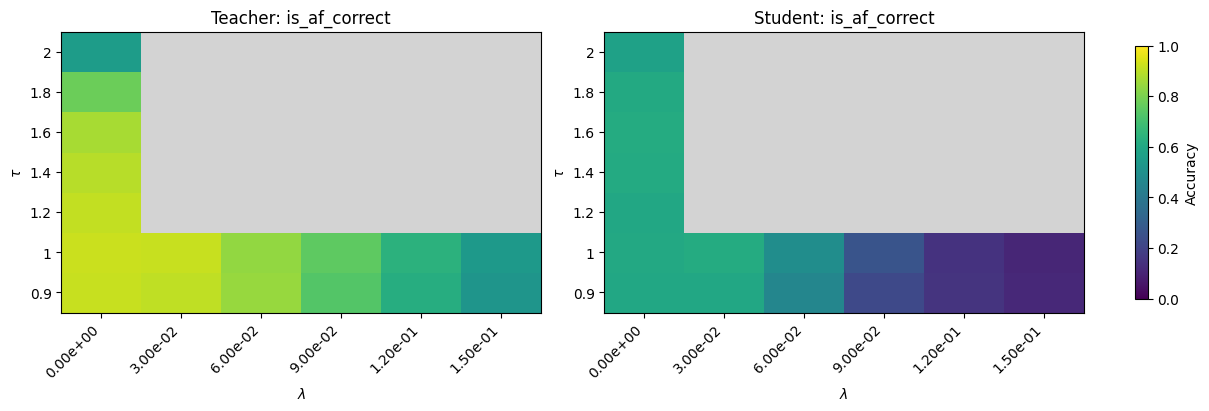

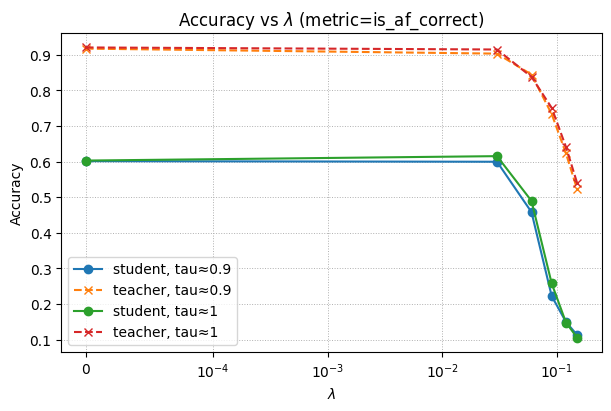

In [13]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ---- config ----
# Prefer a relative path so this works on remote kernels too.
# If your traces live elsewhere, set TRACES_DIR to that absolute path.
TRACES_DIR = Path("experiments/full_pipeline_run2/traces")

# Choose which score to plot (matches columns in the parquet files):
#   - "is_raw_correct"  : correctness of the raw trace answer
#   - "is_af_correct"   : correctness after AF trace transformation
METRIC = "is_af_correct"

EVAL_GLOB = "eval_*_tau*_lam*_eps*.parquet"

def _parse_params(filename: str) -> dict[str, object] | None:
    """Parse eval parquet filenames like:
    eval_teacher_tau1.00e+00_lam3.00e-02_eps1.00e-02.parquet
    """
    name = filename
    if name.endswith(".parquet"):
        name = name[: -len(".parquet")]
    parts = name.split("_")
    if len(parts) < 5:
        return None
    if parts[0] != "eval":
        return None
    kind = parts[1]
    if kind not in {"teacher", "student"}:
        return None
    out: dict[str, object] = {"kind": kind}
    for p in parts[2:]:
        if p.startswith("tau"):
            out["tau"] = float(p[len("tau"):])
        elif p.startswith("lam"):
            out["lam"] = float(p[len("lam"):])
        elif p.startswith("eps"):
            out["eps"] = float(p[len("eps"):])
    if "tau" not in out or "lam" not in out or "eps" not in out:
        return None
    return out

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start

def resolve_traces_dir(traces_dir: Path) -> Path:
    # If caller gave an absolute path, trust it if it exists
    if traces_dir.is_absolute() and traces_dir.exists():
        return traces_dir
    # Otherwise, try relative to repo root
    root = find_repo_root()
    rel = (root / traces_dir).resolve()
    if rel.exists():
        return rel
    # Auto-discover: look for experiments/**/traces that contains eval parquet files
    exp = root / "experiments"
    if exp.exists():
        candidates = []
        for d in exp.glob("**/traces"):
            if any(d.glob(EVAL_GLOB)):
                candidates.append(d)
        if candidates:
            # Prefer most recently modified traces directory
            candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
            return candidates[0]
    return rel  # fall back (will fail with helpful error below)

TRACES_DIR = resolve_traces_dir(TRACES_DIR)
print("Using TRACES_DIR:", TRACES_DIR)

def collect_scores(traces_dir: Path) -> pd.DataFrame:
    paths = sorted(traces_dir.glob(EVAL_GLOB)) if traces_dir.exists() else []
    if not paths:
        root = find_repo_root()
        msg = [
            f"No eval parquet files found under: {traces_dir}",
            f"cwd={Path.cwd().resolve()}",
            f"repo_root={root}",
        ]
        exp = root / "experiments"
        if exp.exists():
            found = [d for d in exp.glob("**/traces") if any(d.glob(EVAL_GLOB))]
            if found:
                msg.append("Discovered traces dirs with eval parquets (showing up to 5):")
                msg.extend(["  - " + str(p) for p in found[:5]])
        raise FileNotFoundError("\n".join(msg))

    rows: list[dict[str, object]] = []
    bad = 0
    for path in paths:
        params = _parse_params(path.name)
        if params is None:
            bad += 1
            continue
        # Read only the score columns so we don't load huge text columns like `trace` / `trace_af`.
        try:
            df = pd.read_parquet(path, columns=["is_raw_correct", "is_af_correct"])
        except Exception:
            df = pd.read_parquet(path)
        row: dict[str, object] = {**params, "file": path.name}
        for col in ["is_raw_correct", "is_af_correct"]:
            if col in df.columns:
                row[col] = float(pd.to_numeric(df[col], errors="coerce").mean())
        rows.append(row)

    if not rows:
        raise FileNotFoundError(
            f"Found {len(paths)} parquet(s) but could not parse any filenames. "
            f"Unparsed={bad}. Example={paths[0].name if paths else 'n/a'}"
        )
    if bad:
        print(f"Warning: could not parse {bad}/{len(paths)} files (unexpected naming)")
    return pd.DataFrame(rows)

scores = collect_scores(TRACES_DIR)
print("Loaded", len(scores), "(kind,tau,lam) points")
display(scores.sort_values(["kind", "tau", "lam"]).head(12))

def make_pivot(scores_df: pd.DataFrame, kind: str, metric: str) -> pd.DataFrame:
    sub = scores_df[scores_df["kind"] == kind].copy()
    if metric not in sub.columns:
        raise KeyError(
            f"Metric {metric!r} not present for kind={kind!r}. "
            f"Available: {sorted(c for c in sub.columns if c.startswith('is_'))}"
        )
    # If duplicates exist (e.g., multiple seeds), average them.
    sub = sub.groupby(["tau", "lam"], as_index=False)[metric].mean()
    return sub.pivot(index="tau", columns="lam", values=metric).sort_index().sort_index(axis=1)

teacher_pivot = make_pivot(scores, "teacher", METRIC)
student_pivot = make_pivot(scores, "student", METRIC)

def plot_heatmap(ax: plt.Axes, pivot: pd.DataFrame, title: str, vmin: float, vmax: float):
    masked = np.ma.masked_invalid(pivot.to_numpy(dtype=float))
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="lightgray")
    im = ax.imshow(masked, origin="lower", aspect="auto", vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$\tau$")
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels([f"{v:.2e}" for v in pivot.columns], rotation=45, ha="right")
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels([f"{v:.2g}" for v in pivot.index])
    return im

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
plot_heatmap(axes[0], teacher_pivot, f"Teacher: {METRIC}", vmin=0.0, vmax=1.0)
im = plot_heatmap(axes[1], student_pivot, f"Student: {METRIC}", vmin=0.0, vmax=1.0)
cbar = fig.colorbar(im, ax=axes, shrink=0.9)
cbar.set_label("Accuracy")
plt.show()

# Optional: Fig-3-style curves (accuracy vs lambda for selected taus)
TAU_SLICES = [0.9, 1.0]

def nearest_tau(pivot: pd.DataFrame, tau_target: float) -> float | None:
    taus = pivot.index.to_numpy(dtype=float)
    if taus.size == 0:
        return None
    return float(taus[int(np.argmin(np.abs(taus - tau_target)))])

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
for tau_target in TAU_SLICES:
    tau_s = nearest_tau(student_pivot, tau_target)
    if tau_s is not None:
        ax.plot(student_pivot.columns, student_pivot.loc[tau_s].values, marker="o", label=f"student, tau≈{tau_s:g}")
    tau_t = nearest_tau(teacher_pivot, tau_target)
    if tau_t is not None:
        ax.plot(teacher_pivot.columns, teacher_pivot.loc[tau_t].values, marker="x", linestyle="--", label=f"teacher, tau≈{tau_t:g}")

ax.set_xscale("symlog", linthresh=1e-4)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("Accuracy")
ax.set_title(f"Accuracy vs $\\lambda$ (metric={METRIC})")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
ax.legend()
plt.show()

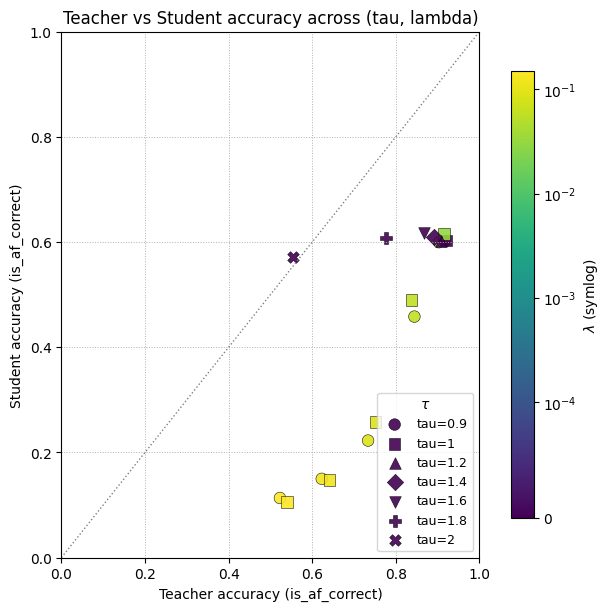

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Requires `scores` and `METRIC` from Cell 8
dfm = scores.copy()

# Aggregate in case you have repeats (e.g., multiple seeds/files per (tau, lam))
dfm = dfm.groupby(["tau", "lam", "kind"], as_index=False)[METRIC].mean()

# Pivot into columns: teacher, student
paired = dfm.pivot(index=["tau", "lam"], columns="kind", values=METRIC).reset_index()

if "teacher" not in paired.columns or "student" not in paired.columns:
    raise ValueError(f"Need both teacher and student rows. Columns present: {list(paired.columns)}")

# Marker by tau, color by lambda
taus = np.sort(paired["tau"].unique())
markers = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "+"]
marker_map = {t: markers[i % len(markers)] for i, t in enumerate(taus)}

lam_vals = paired["lam"].to_numpy(dtype=float)
lam_min = float(np.nanmin(lam_vals))
lam_max = float(np.nanmax(lam_vals))

# Use symlog normalization so lambda=0 is representable
norm = mpl.colors.SymLogNorm(linthresh=1e-4, vmin=lam_min, vmax=lam_max)
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
for t in taus:
    sub = paired[paired["tau"] == t]
    ax.scatter(
        sub["teacher"],
        sub["student"],
        c=sub["lam"],
        cmap=cmap,
        norm=norm,
        marker=marker_map[t],
        s=70,
        edgecolors="black",
        linewidths=0.4,
        alpha=0.9,
        label=f"tau={t:g}",
    )

# y=x reference
ax.plot([0, 1], [0, 1], linestyle=":", color="gray", linewidth=1.0)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel(f"Teacher accuracy ({METRIC})")
ax.set_ylabel(f"Student accuracy ({METRIC})")
ax.set_title("Teacher vs Student accuracy across (tau, lambda)")
ax.grid(True, linestyle=":", linewidth=0.7)

# Colorbar for lambda
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.85)
cbar.set_label(r"$\lambda$ (symlog)")

# Legend for tau markers
ax.legend(title=r"$\tau$", loc="lower right", fontsize=9)
plt.show()